In [1]:
import torch
import torchvision
from torchvision.transforms import transforms
import numpy as np
from matplotlib import pyplot as plt
from torchvision.transforms.v2 import GaussianNoise
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset

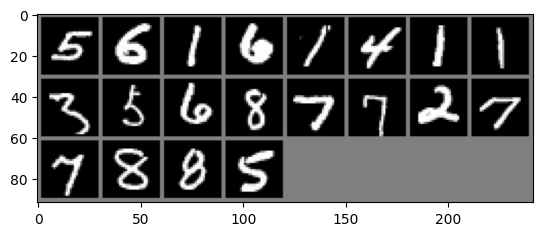

torch.Size([20, 1, 28, 28])

In [12]:
BATCH_SIZE = 20
STEPS = 10

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0.5, 0.5)])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

valset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
dataiter = iter(trainloader)
images,_ = next(dataiter)
imshow(torchvision.utils.make_grid(images))

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__() #input of 1*28*28

        self.conv1 = nn.Conv2d(1, 16, 3, padding="same") # 1 to 16
        self.conv2 = nn.Conv2d(16, 32, 3, padding="same") # 16 to 32
        self.conv3 = nn.Conv2d(32, 64, 3, padding="same") # 32 to 64

        self.pool = nn.MaxPool2d(2, 2, return_indices=True) # divide image size by 2
        self.unpool = nn.MaxUnpool2d(2, 2) #multiply image size by 2

        self.conv4 = nn.Conv2d(64, 32, 3, padding="same") # 64 to 32
        self.conv5 = nn.Conv2d(64, 16, 3, padding="same") # 64 to 16
        self.conv6 = nn.Conv2d(32, 1, 3, padding="same") # 32 to 1


    def forward(self, x): # 1*28*28
        x1 = F.leaky_relu(self.conv1(x)) #16*28*28

        x2, indices1 = self.pool(x1) #16*14*14
        x2 = F.leaky_relu(self.conv2(x2)) #32*14*14

        x3, indices2 = self.pool(x2) #32*7*7
        x3 = F.leaky_relu(self.conv3(x3)) #64*7*7
        x3 = F.leaky_relu(self.conv4(x3)) #32*7*70
        x3 = self.unpool(x3, indices2) #32*14*14

        x = torch.cat((x2, x3), dim=1) #64*14*14
        x = F.leaky_relu(self.conv5(x)) #16*14*14
        x = self.unpool(x, indices1) #16*28*28

        x = torch.cat((x1,x), dim=1) #32*28*28
        x = F.leaky_relu(self.conv6(x)) #1*28*28

        return x

In [13]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, writer, device):
    gaussian = GaussianNoise(0,0.3)
    min_loss = float('inf')
    early_stopping = 0

    # Training and validation
    for i in range(num_epochs):
        epoch_training_loss = 0
        epoch_validation_loss = 0

        # Evaluation of the model
        model.eval()
        for _,(images,_) in enumerate(val_loader):
            # Convert images to tensor
            images = torch.Tensor(images).type('torch.FloatTensor')

            # apply STEPS steps of noising and validating the network
            for i in range(STEPS):
                # define input and target
                target_imgs = images.to(device)
                images = gaussian(images).to(device)

                # Forward pass
                outputs = model.forward(images)

                # Compute loss
                loss = criterion(outputs, target_imgs)

                # Update loss
                epoch_validation_loss += loss.detach().numpy()
        v_loss = epoch_validation_loss/len(val_loader.dataset)
        writer.add_scalar('Loss/evaluation', v_loss, i)

        if v_loss<min_loss:
            torch.save(model, 'best_model.pt')
            min_loss = loss
            early_stopping = 0
        else:
            early_stopping += 1

        if early_stopping >= 5:
            break

        # Train model
        model.train()
        for _,(images,_) in enumerate(train_loader):
            # Convert images to tensor
            images = torch.Tensor(images).type('torch.FloatTensor')

            # apply STEPS steps of noising and training the network
            for i in range(STEPS):
                # define input and target
                target_imgs = images.to(device)
                images = gaussian(images).to(device)

                # Forward pass
                outputs = model.forward(images)

                # Compute loss
                loss = criterion(outputs, target_imgs)

                # Reset gradients
                optimizer.zero_grad()

                # Compute gradients
                loss.backward()

                # Update weights
                optimizer.step()

                # Update loss
                epoch_training_loss += loss.detach().numpy()
        t_loss = epoch_training_loss/len(train_loader.dataset)
        writer.add_scalar('Loss/training', t_loss, i)

        if i % 1 == 0:
            print(f'Epoch {i}, training loss: {t_loss}')

            img = torch.from_numpy((np.random.rand(1,1,28,28) - 0.5)*2).type('torch.FloatTensor').to(device)
            res = img
            for i in range(STEPS):
                img = net.forward(img)
                res = torch.cat((res,img), dim=0)
            imshow(torchvision.utils.make_grid(res))

    return model

In [5]:
from torch.utils.tensorboard import SummaryWriter
from torch import optim

# defining the model
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.MSELoss()
epochs = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)

In [ ]:
writer = SummaryWriter(comment='diffusionModel')
net = train_model(net, criterion, optimizer, trainloader, valloader, epochs, writer, device)
writer.close()